In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import sys
import os
import nltk
nltk.download('vader_lexicon')
sys.path.insert(0, os.path.abspath('..'))
from nltk.sentiment import SentimentIntensityAnalyzer
from scipy import stats
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
# from src.data_loader import load_data, remove_nulls,show_duplicates,fill_nulls,prepare_dates,align_news_and_stock_dates
from src.analysis import get_sentiment_score,classify_sentiment
from src.data_loader_copy import load_data, remove_nulls,show_duplicates,fill_nulls,prepare_dates,align_news_and_stock_dates,prepare_dates_cluster
from src.plot import plot_sentiment_category_distribution,plot_sentiment_vs_returns_all,plot_average_return_by_sentiment

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\bemnet\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\bemnet\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\bemnet\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


# Import Data

In [2]:
aapl_df = load_data("../data/raw/Data/AAPL.csv")
amzn_df = load_data("../data/raw/Data/AMZN.csv")
meta_df = load_data("../data/raw/Data/META.csv")
goog_df = load_data("../data/raw/Data/GOOG.csv")
nvda_df = load_data("../data/raw/Data/NVDA.csv")
news_df = load_data("../data/raw/raw_analyst_ratings.csv")

# Date Preparation

In [3]:
news_df,amzn_df,meta_df,goog_df,aapl_df,nvda_df = prepare_dates_cluster(
    news_df,
    amzn_df,
    meta_df,
    goog_df,
    aapl_df,
    nvda_df
)


# Align Dates

In [4]:
aligned_data= align_news_and_stock_dates(
    news_df,
    amzn_df,
    meta_df,
    goog_df,
    aapl_df,
    nvda_df
)
aapl_aligned = aligned_data['AAPL']
goog_aligned = aligned_data['GOOG']
amzn_aligned = aligned_data['AMZN']
meta_aligned = aligned_data['META']
nvda_aligned = aligned_data['NVDA']

# Generate Sentiment Scores

In [5]:
# ==========================================
# Combine All Unique Headlines
# ==========================================

unique_headlines = pd.concat([
    aapl_aligned['headline'],
    goog_aligned['headline'],
    amzn_aligned['headline'],
    meta_aligned['headline'],
    nvda_aligned['headline']
]).dropna().unique()


# ==========================================
# Calculate Sentiment Once
# ==========================================

sentiment_map = {
    headline: get_sentiment_score(headline)
    for headline in unique_headlines
}


# ==========================================
# Apply Sentiment Scores
# ==========================================

aapl_aligned['Sentiment_Score'] = (
    aapl_aligned['headline']
    .map(sentiment_map)
)

goog_aligned['Sentiment_Score'] = (
    goog_aligned['headline']
    .map(sentiment_map)
)

amzn_aligned['Sentiment_Score'] = (
    amzn_aligned['headline']
    .map(sentiment_map)
)

meta_aligned['Sentiment_Score'] = (
    meta_aligned['headline']
    .map(sentiment_map)
)

nvda_aligned['Sentiment_Score'] = (
    nvda_aligned['headline']
    .map(sentiment_map)
)

# Merge Sentiment with Stock Data

In [6]:
# Store Stock DataFrames

stock_datasets = {
    'AAPL': aapl_df,
    'GOOG': goog_df,
    'AMZN': amzn_df,
    'META': meta_df,
    'NVDA': nvda_df
}



# Store Aligned News DataFrames

aligned_datasets = {
    'AAPL': aapl_aligned,
    'GOOG': goog_aligned,
    'AMZN': amzn_aligned,
    'META': meta_aligned,
    'NVDA': nvda_aligned
}


# Merge Sentiment with Stock Data

merged_datasets = {}

for ticker in stock_datasets.keys():

    # Get stock dataframe
    stock_df = stock_datasets[ticker].copy()

    # Get aligned dataframe
    aligned_df = aligned_datasets[ticker].copy()

    # --------------------------------------
    # Sort stock data
    # --------------------------------------

    stock_df = stock_df.sort_values(
        'Date'
    )

    
    # Calculate Daily Return


    stock_df['daily_return'] = (
        stock_df['Close']
        .pct_change()
    ) * 100

   
    # Aggregate Daily Sentiment

    daily_sentiment = (
        aligned_df
        .groupby('trading_date')['Sentiment_Score']
        .mean()
        .reset_index()
    )

    # Merge DataFrames
   

    merged_df = pd.merge(
        daily_sentiment,
        stock_df,
        left_on='trading_date',
        right_on='Date',
        how='inner'
    )

    # Store result
    merged_datasets[ticker] = merged_df




# Pearson Correlation

In [7]:

# Calculate Correlation for All Stocks


correlation_results = {}

for ticker, df in merged_datasets.items():

    correlation = df[
        'Sentiment_Score'
    ].corr(
        df['daily_return']
    )

    correlation_results[ticker] = correlation

# Display Results

for ticker, correlation in correlation_results.items():

    print(
        f"{ticker} Correlation "
        f"(Sentiment vs Daily Return): "
        f"{correlation}"
    )

AAPL Correlation (Sentiment vs Daily Return): 0.13913216165530298
GOOG Correlation (Sentiment vs Daily Return): 0.12226652786891556
AMZN Correlation (Sentiment vs Daily Return): 0.07928380482652381
META Correlation (Sentiment vs Daily Return): 0.1503303088465398
NVDA Correlation (Sentiment vs Daily Return): 0.10995311856319576


# Plots

## Sentiment Score vs Daily Returns

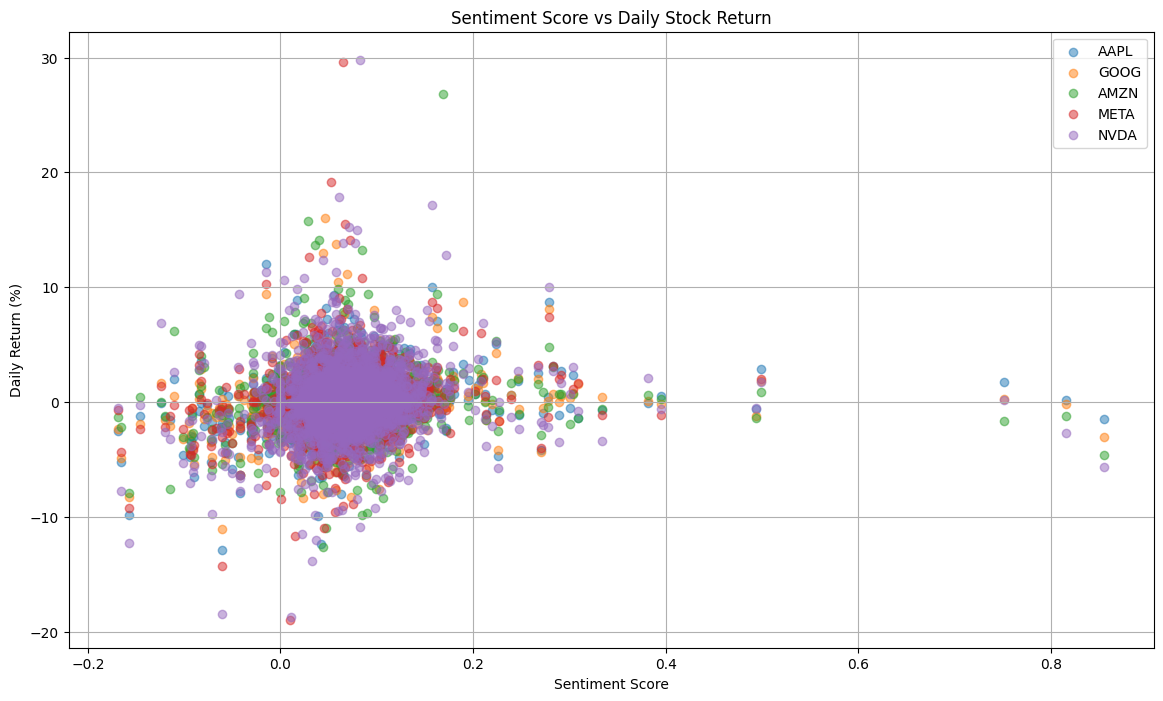

In [10]:
plot_sentiment_vs_returns_all(
    merged_datasets
)

#### Sentiment Score vs Daily Stock Return Analysis

The analysis shows a weak positive correlation between news sentiment and daily stock returns across all five companies. Meta Platforms showed the strongest relationship with a correlation coefficient of 0.150, followed by Apple (0.139), Alphabet/Google (0.122), NVIDIA (0.110), and Amazon (0.079).

Although the correlations are positive, all values remain relatively low, indicating that news sentiment had only a limited influence on short-term stock price movements. The scatter distribution further confirms that most daily returns remained clustered near zero regardless of sentiment intensity, suggesting that additional market factors beyond news sentiment significantly affected stock performance.

# Classify Sentiment Categories

In [11]:
for ticker, df in merged_datasets.items():

    df['sentiment_category'] = (
        df['Sentiment_Score']
        .apply(classify_sentiment)
    )

    # Update dictionary
    merged_datasets[ticker] = df

### Sentiment Category Distribution

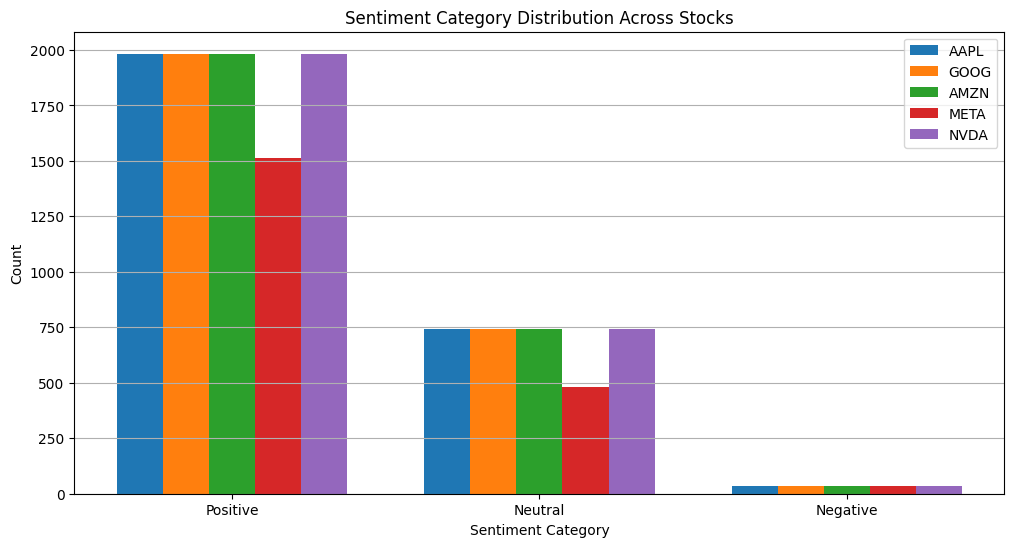

In [12]:
plot_sentiment_category_distribution(
    merged_datasets
)


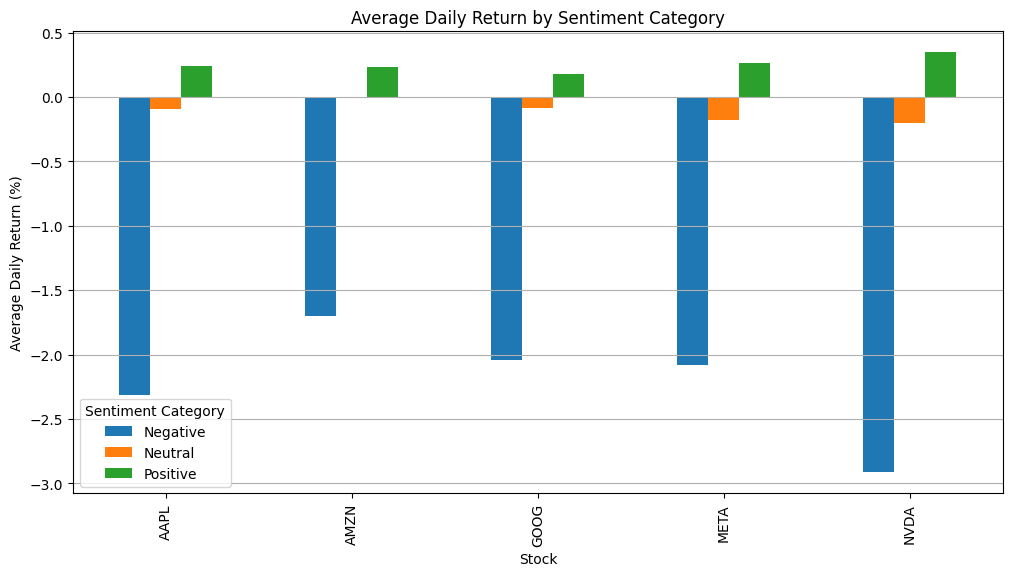

In [13]:
plot_average_return_by_sentiment(
    merged_datasets
)

### Average Daily Return by Sentiment Category Analysis

The visualization shows a consistent relationship between sentiment categories and stock performance across all five companies. Positive sentiment days generally produced positive average daily returns, while negative sentiment days were associated with the largest negative returns. Neutral sentiment days resulted in returns close to zero, indicating limited market movement.

NVIDIA experienced the strongest negative average return during negative sentiment periods, while also showing the highest positive average return during positive sentiment periods. Overall, the results suggest that market sentiment had a noticeable influence on short-term stock price behavior, with positive sentiment linked to gains and negative sentiment linked to losses.